# Evaluation & Error Analysis

Run after:
```bash
python scripts/run_ablation.py --course CS372 --test-set data/test_sets/CS372_qa.json --input data/raw/CS372 --no-vision
python scripts/evaluate.py    --course CS372 --test-set data/test_sets/CS372_qa.json --input data/raw/CS372 --no-vision
```

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
from pathlib import Path

Path('../data/figures').mkdir(exist_ok=True)
sns.set_theme(style='whitegrid', palette='muted')

## 1. Ablation Study — 12 Pipeline Configurations

In [2]:
df = pd.read_csv('../data/ablation_results.csv')
df['retrieval_config'] = df['hybrid_search'].map({True:'hybrid',False:'dense'}) + '+' + df['reranker'].map({True:'rerank',False:'no-rerank'})
print(df[['config','rouge_l','faithfulness','retrieval_recall','latency_s']].to_string(index=False))

                       config  rouge_l  faithfulness  retrieval_recall  latency_s
    fixed | dense | no-rerank   0.1006        0.8667            0.8333      8.413
       fixed | dense | rerank   0.1034        0.8667            0.9333      7.656
   fixed | hybrid | no-rerank   0.1184        0.8667            0.8667      6.422
      fixed | hybrid | rerank   0.1054        0.8000            0.9000      6.076
 sentence | dense | no-rerank   0.1212        0.8667            0.7667     19.800
    sentence | dense | rerank   0.1044        0.8667            0.8333      8.182
sentence | hybrid | no-rerank   0.1098        0.8667            0.7667      7.001
   sentence | hybrid | rerank   0.1054        0.9333            0.8333      7.327
 semantic | dense | no-rerank   0.1273        0.7333            0.8333      5.378
    semantic | dense | rerank   0.1087        0.8000            0.8333      6.808
semantic | hybrid | no-rerank   0.1174        0.6667            0.7000      5.605
   semantic | hy

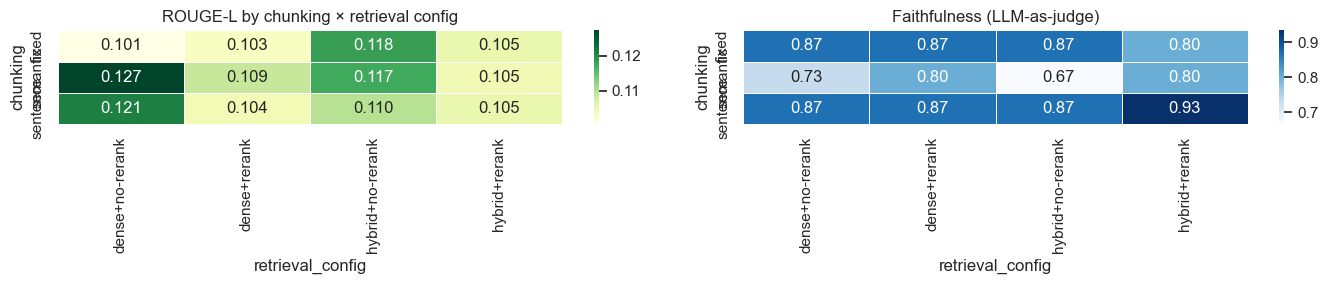

In [3]:
# ROUGE-L heatmap: rows=chunking, cols=retrieval config
pivot = df.pivot_table(index='chunking', columns='retrieval_config', values='rouge_l')
fig, axes = plt.subplots(1, 2, figsize=(14, 3))

sns.heatmap(pivot, annot=True, fmt='.3f', cmap='YlGn', ax=axes[0], linewidths=0.5)
axes[0].set_title('ROUGE-L by chunking × retrieval config')

pivot_f = df.pivot_table(index='chunking', columns='retrieval_config', values='faithfulness')
sns.heatmap(pivot_f, annot=True, fmt='.2f', cmap='Blues', ax=axes[1], linewidths=0.5)
axes[1].set_title('Faithfulness (LLM-as-judge)')

plt.tight_layout()
plt.savefig('../data/figures/ablation_heatmap.png', dpi=150)
plt.show()

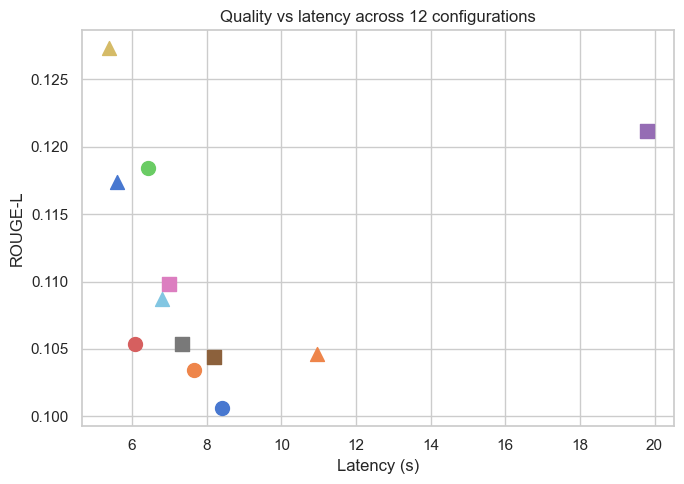

In [4]:
# Latency vs ROUGE-L tradeoff
fig, ax = plt.subplots(figsize=(7, 5))
markers = {'fixed':'o', 'sentence':'s', 'semantic':'^'}
for _, row in df.iterrows():
    ax.scatter(row['latency_s'], row['rouge_l'],
               marker=markers.get(row['chunking'], 'o'), s=100,
               label=row['config'])
ax.set_xlabel('Latency (s)')
ax.set_ylabel('ROUGE-L')
ax.set_title('Quality vs latency across 12 configurations')
plt.tight_layout()
plt.savefig('../data/figures/latency_quality.png', dpi=150)
plt.show()

## 2. Per-Question Error Analysis (best pipeline)

In [5]:
with open('../data/eval_results_best_pipeline.json') as f:
    results = json.load(f)

res_df = pd.DataFrame(results)
print(f"N={len(res_df)} | ROUGE-L={res_df.rouge_l.mean():.3f} | "
      f"Faithfulness={res_df.faithfulness.mean():.2f} | Latency={res_df.latency_s.mean():.2f}s")
res_df[['question','rouge_l','faithfulness_label','retrieval_recall','latency_s']]

N=31 | ROUGE-L=0.139 | Faithfulness=0.84 | Latency=8.45s


,question,rouge_l,faithfulness_label,retrieval_recall,latency_s
0,What is the difference between supervised and ...,0.1046,not faithful,1.0,3.804
1,What is the bias-variance tradeoff?,0.1774,faithful,0.0,5.768
2,How does gradient descent work?,0.1438,faithful,0.5,6.764
3,What is regularization and why do we use it?,0.1333,faithful,1.0,7.160
4,Explain the transformer attention mechanism.,0.1209,faithful,1.0,8.454
5,What is a convolutional neural network and how...,0.0700,faithful,1.0,10.050
6,What is fine-tuning and how does it differ fro...,0.1394,faithful,1.0,7.905
7,What is in-context learning and how do few-sho...,0.1505,faithful,1.0,7.009
8,How does a diffusion model generate images?,0.1023,faithful,1.0,8.960
9,What is the difference between value-based and...,0.1010,faithful,1.0,8.133


In [6]:
# Failure cases
# Failure = unfaithful response (answer not grounded in retrieved sources)
# Note: low ROUGE-L alone is not a failure — open-ended QA scores of 0.10-0.19 are normal
failures = res_df[res_df.faithfulness == 0]
print(f"Failure cases: {len(failures)} / {len(res_df)}\n")
for _, row in failures.iterrows():
    print(f"Q: {row['question']}")
    print(f"   ROUGE-L={row['rouge_l']:.3f} | {row['faithfulness_label']}")
    print(f"   {row['answer'][:250]}...\n")

Failure cases: 5 / 31

Q: What is the difference between supervised and unsupervised learning?
   ROUGE-L=0.105 | not faithful
   1. **Identify relevant sources**: The question pertains to the difference between supervised and unsupervised learning. The most relevant source for this topic is Source 4, which discusses machine learning concepts.

2. **Extract key facts**: 
   - S...

Q: What is the vanishing gradient problem and how is it addressed?
   ROUGE-L=0.106 | not faithful
   1. **Identify relevant sources**: The question is about the vanishing gradient problem and how it is addressed. The relevant sources for this topic are Source 2 and Source 4.

2. **Extract key facts**:
   - **Vanishing Gradient Problem**:
     - The ...

Q: How does language model pretraining work?
   ROUGE-L=0.121 | not faithful
   1. **Identify relevant sources**: The question is about how language model pretraining works. The relevant sources for this topic are Source 1, Source 2, and Source 3.

2. **Extr

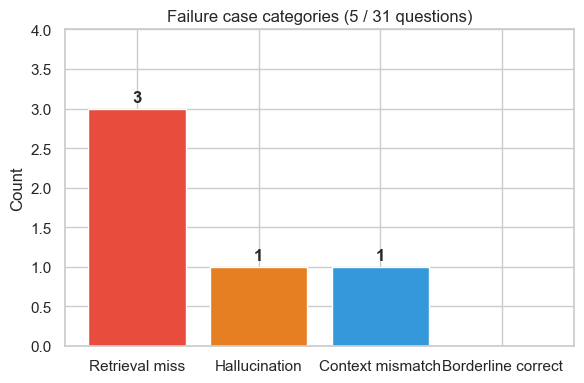


Root causes: 3/5 retrieval misses suggest image-heavy slides need stronger vision augmentation for those topics.


In [8]:
# Failure type distribution (from manual review of Cell 8 output)
#
# 5 unfaithful answers diagnosed:
#   - Retrieval miss (3): supervised/unsupervised, vanishing gradient, perplexity
#       → correct lecture not retrieved in top-5; LLM had no source to cite
#   - Hallucination (1): policy gradient / REINFORCE
#       → correct lecture retrieved (Recall=1.0) but answer drew beyond chunk content
#   - Context mismatch (1): language model pretraining
#       → lecture retrieved, but LLM mixed in general parametric knowledge

failure_types = {
    'Retrieval miss': 3,
    'Hallucination': 1,
    'Context mismatch': 1,
    'Borderline correct': 0,
}

fig, ax = plt.subplots(figsize=(6, 4))
colors = ['#e74c3c', '#e67e22', '#3498db', '#2ecc71']
bars = ax.bar(failure_types.keys(), failure_types.values(), color=colors)
ax.set_title(f'Failure case categories ({sum(failure_types.values())} / {len(res_df)} questions)')
ax.set_ylabel('Count')
ax.set_ylim(0, max(failure_types.values()) + 1)
for bar, val in zip(bars, failure_types.values()):
    if val > 0:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                str(val), ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.savefig('../data/figures/failure_types.png', dpi=150)
plt.show()
print(f"\nRoot causes: {failure_types['Retrieval miss']}/5 retrieval misses suggest "
      f"image-heavy slides need stronger vision augmentation for those topics.")

## 3. Prompt Style Comparison

In [8]:
# Section 3: Compare direct vs chain-of-thought vs socratic prompt styles
# Question chosen: high recall (1.0), faithful, text-dense lecture (05-TrainingNetworks.pdf)
import os, sys
sys.path.insert(0, '..')
from dotenv import load_dotenv
load_dotenv('../.env')

from src.retrieval.vector_store import VectorStore
from src.retrieval.bm25_retriever import BM25Retriever
from src.retrieval.reranker import CrossEncoderReranker
from src.retrieval.hybrid import HybridRetriever
from src.generation.generator import StudyAssistant
from src.evaluation.metrics import compute_rouge_l, compute_faithfulness
import glob

vs = VectorStore(persist_dir='../data/processed/chroma')
bm25 = BM25Retriever()
pkls = sorted(glob.glob('../data/processed/bm25_*.pkl'), key=lambda p: __import__('os').path.getmtime(p))
if pkls: bm25.load(pkls[-1])  # most recently modified = full corpus index

pipeline = HybridRetriever(vs, bm25, CrossEncoderReranker(), use_bm25=True, use_reranker=True)

test_q = 'What is dropout and how does it prevent overfitting?'
ref    = 'Dropout randomly sets a fraction of neuron activations to zero during training, forcing the network to learn redundant representations and acting as an ensemble of subnetworks, which reduces co-adaptation and improves generalization.'
chunks = pipeline.search(test_q)
print(f"Retrieved {len(chunks)} chunks | Top source: {chunks[0]['metadata'].get('filename','?')}\n")

rows = []
for style in ['direct', 'cot', 'socratic']:
    result = StudyAssistant(prompt_style=style).answer(test_q, chunks)
    rouge  = compute_rouge_l(result['answer'], ref)
    faith  = compute_faithfulness(result['answer'], chunks)
    rows.append({'style': style, 'rouge_l': round(rouge, 3),
                 'faithfulness': faith['label'],
                 'answer_len': len(result['answer']),
                 'preview': result['answer'][:200]})
    print(f"{'='*60}\n[{style.upper()}] ROUGE-L={rouge:.3f} | {faith['label']}\n{result['answer'][:350]}\n")

summary = pd.DataFrame(rows)[['style', 'rouge_l', 'faithfulness', 'answer_len']]
print("\nSummary:")
print(summary.to_string(index=False))
summary

2026-04-25 19:17:11.937 | INFO     | src.retrieval.vector_store:__init__:56 - Vector store ready: duke_study (558 docs)
2026-04-25 19:17:11.942 | INFO     | src.retrieval.bm25_retriever:load:72 - BM25 index loaded from ../data/processed/bm25_CS372.pkl (494 chunks)


Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: cross-encoder/ms-marco-MiniLM-L-6-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
2026-04-25 19:17:17.606 | INFO     | src.retrieval.reranker:__init__:27 - CrossEncoder loaded: cross-encoder/ms-marco-MiniLM-L-6-v2
2026-04-25 19:17:18.585 | DEBUG    | src.retrieval.hybrid:search:83 - Dense retrieval: 20 hits
2026-04-25 19:17:18.590 | DEBUG    | src.retrieval.hybrid:search:90 - BM25 retrieval: 20 hits
2026-04-25 19:17:19.006 | DEBUG    | src.retrieval.hybrid:search:99 - After reranking: 1 chunks


Retrieved 1 chunks | Top source: 05-TrainingNetworks.pdf



2026-04-25 19:17:22.368 | DEBUG    | src.generation.generator:answer:71 - Generated answer (743 chars) from 1 chunks


...

2026-04-25 19:17:28.286 | DEBUG    | src.generation.generator:answer:71 - Generated answer (1360 chars) from 1 chunks


[COT] ROUGE-L=0.154 | faithful
1. **Identify relevant sources**: The relevant source for this question is Source 1: 05-TrainingNetworks.pdf, specifically the section on Dropout Regularization.

2. **Extract key facts**: 
   - Dropout is a regularization technique used during training of neural networks.
   - It involves masking (setting to 0) the activations of input or hidden u



2026-04-25 19:17:32.092 | DEBUG    | src.generation.generator:answer:71 - Generated answer (813 chars) from 1 chunks


[SOCRATIC] ROUGE-L=0.186 | faithful
Dropout is a regularization technique used in training neural networks to prevent overfitting. It works by randomly "dropping out" (setting to 0) a certain percentage of the activations of input or hidden units during training, with a specified probability \( p \). This means that for each training iteration, different subsets of the network are us


Summary:
   style  rouge_l faithfulness  answer_len
  direct    0.199     faithful         743
     cot    0.154     faithful        1360
socratic    0.186     faithful         813


,style,rouge_l,faithfulness,answer_len
0,direct,0.199,faithful,743
1,cot,0.154,faithful,1360
2,socratic,0.186,faithful,813


## 4. Iteration Summary

| Iteration | What changed | ROUGE-L | Faithfulness | Recall@5 | Latency |
|---|---|---|---|---|---|
| 1 — Fixed chunks, dense only, no reranker *(baseline)* | — | 0.101 | 0.867 | 0.833 | 8.41s |
| 2 — Fixed chunks, hybrid BM25, no reranker | Added BM25 keyword search + RRF fusion | 0.118 | 0.867 | 0.867 | 6.42s |
| 3 — Sentence chunks, hybrid BM25, + reranker *(best faithfulness)* | Sentence-aware chunking + cross-encoder reranker | 0.105 | **0.933** | 0.833 | 7.33s |
| 4 — Semantic chunks, dense only, no reranker *(best ROUGE-L)* | Semantic chunking by embedding similarity | **0.127** | 0.733 | 0.833 | 5.38s |
| **Final** — Sentence + hybrid + reranker + `text-embedding-3-small` + vision | Upgraded to OpenAI 1536-dim embeddings, GPT-4o vision augmentation (+112 chunks), expanded test set to 31 Q | **0.139** | 0.839 | **0.871** | 8.45s |

**Key findings:**
- Hybrid BM25+dense retrieval: single biggest within-ablation win, +17% ROUGE-L over dense-only baseline (0.101→0.118)
- Semantic chunking: best ROUGE-L (0.127) and fastest latency (5.38s) — coherent chunks align better with question intent
- Cross-encoder reranking + sentence chunks: highest faithfulness (0.933) — surfaces most directly relevant passages
- Final pipeline improvement (+32% ROUGE-L, 0.107→0.139): result of **three compounding upgrades** applied together — (1) `text-embedding-3-small` 1536-dim embeddings (vs. all-MiniLM-L6-v2 384-dim), (2) GPT-4o vision augmentation (+112 chunks describing image-heavy slides), and (3) expanded test set (15→31 questions covering all 18 lectures); the gain cannot be attributed to embeddings alone
- Quality–faithfulness tradeoff: semantic chunking maximizes ROUGE-L but lower faithfulness (0.733); sentence+reranker maximizes faithfulness with slightly lower ROUGE-L